In [1]:
import numpy as np
import pandas as pd
import os, re, glob
from scipy.stats import ecdf
from scipy.stats import gaussian_kde

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.tri as mtri
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

# plt.rcParams.update({
#     'font.family': 'serif',
#     'font.size': 12,
#     'axes.labelsize': 12,
#     'xtick.labelsize': 10,
#     'ytick.labelsize': 10,
#     'legend.fontsize': 10,
# })
# plt.style.use('default')
cmap = sns.color_palette('mako', as_cmap=True)

### PDF Plot

In [2]:
base_url = './data/results/'
os.listdir = os.path.dirname(base_url)

In [3]:
fns = glob.glob('data/results/rosette_*.csv')
fns = sorted(fns, key=lambda x: int(re.search(r'rosette_(\d+)\.csv$', x).group(1)))

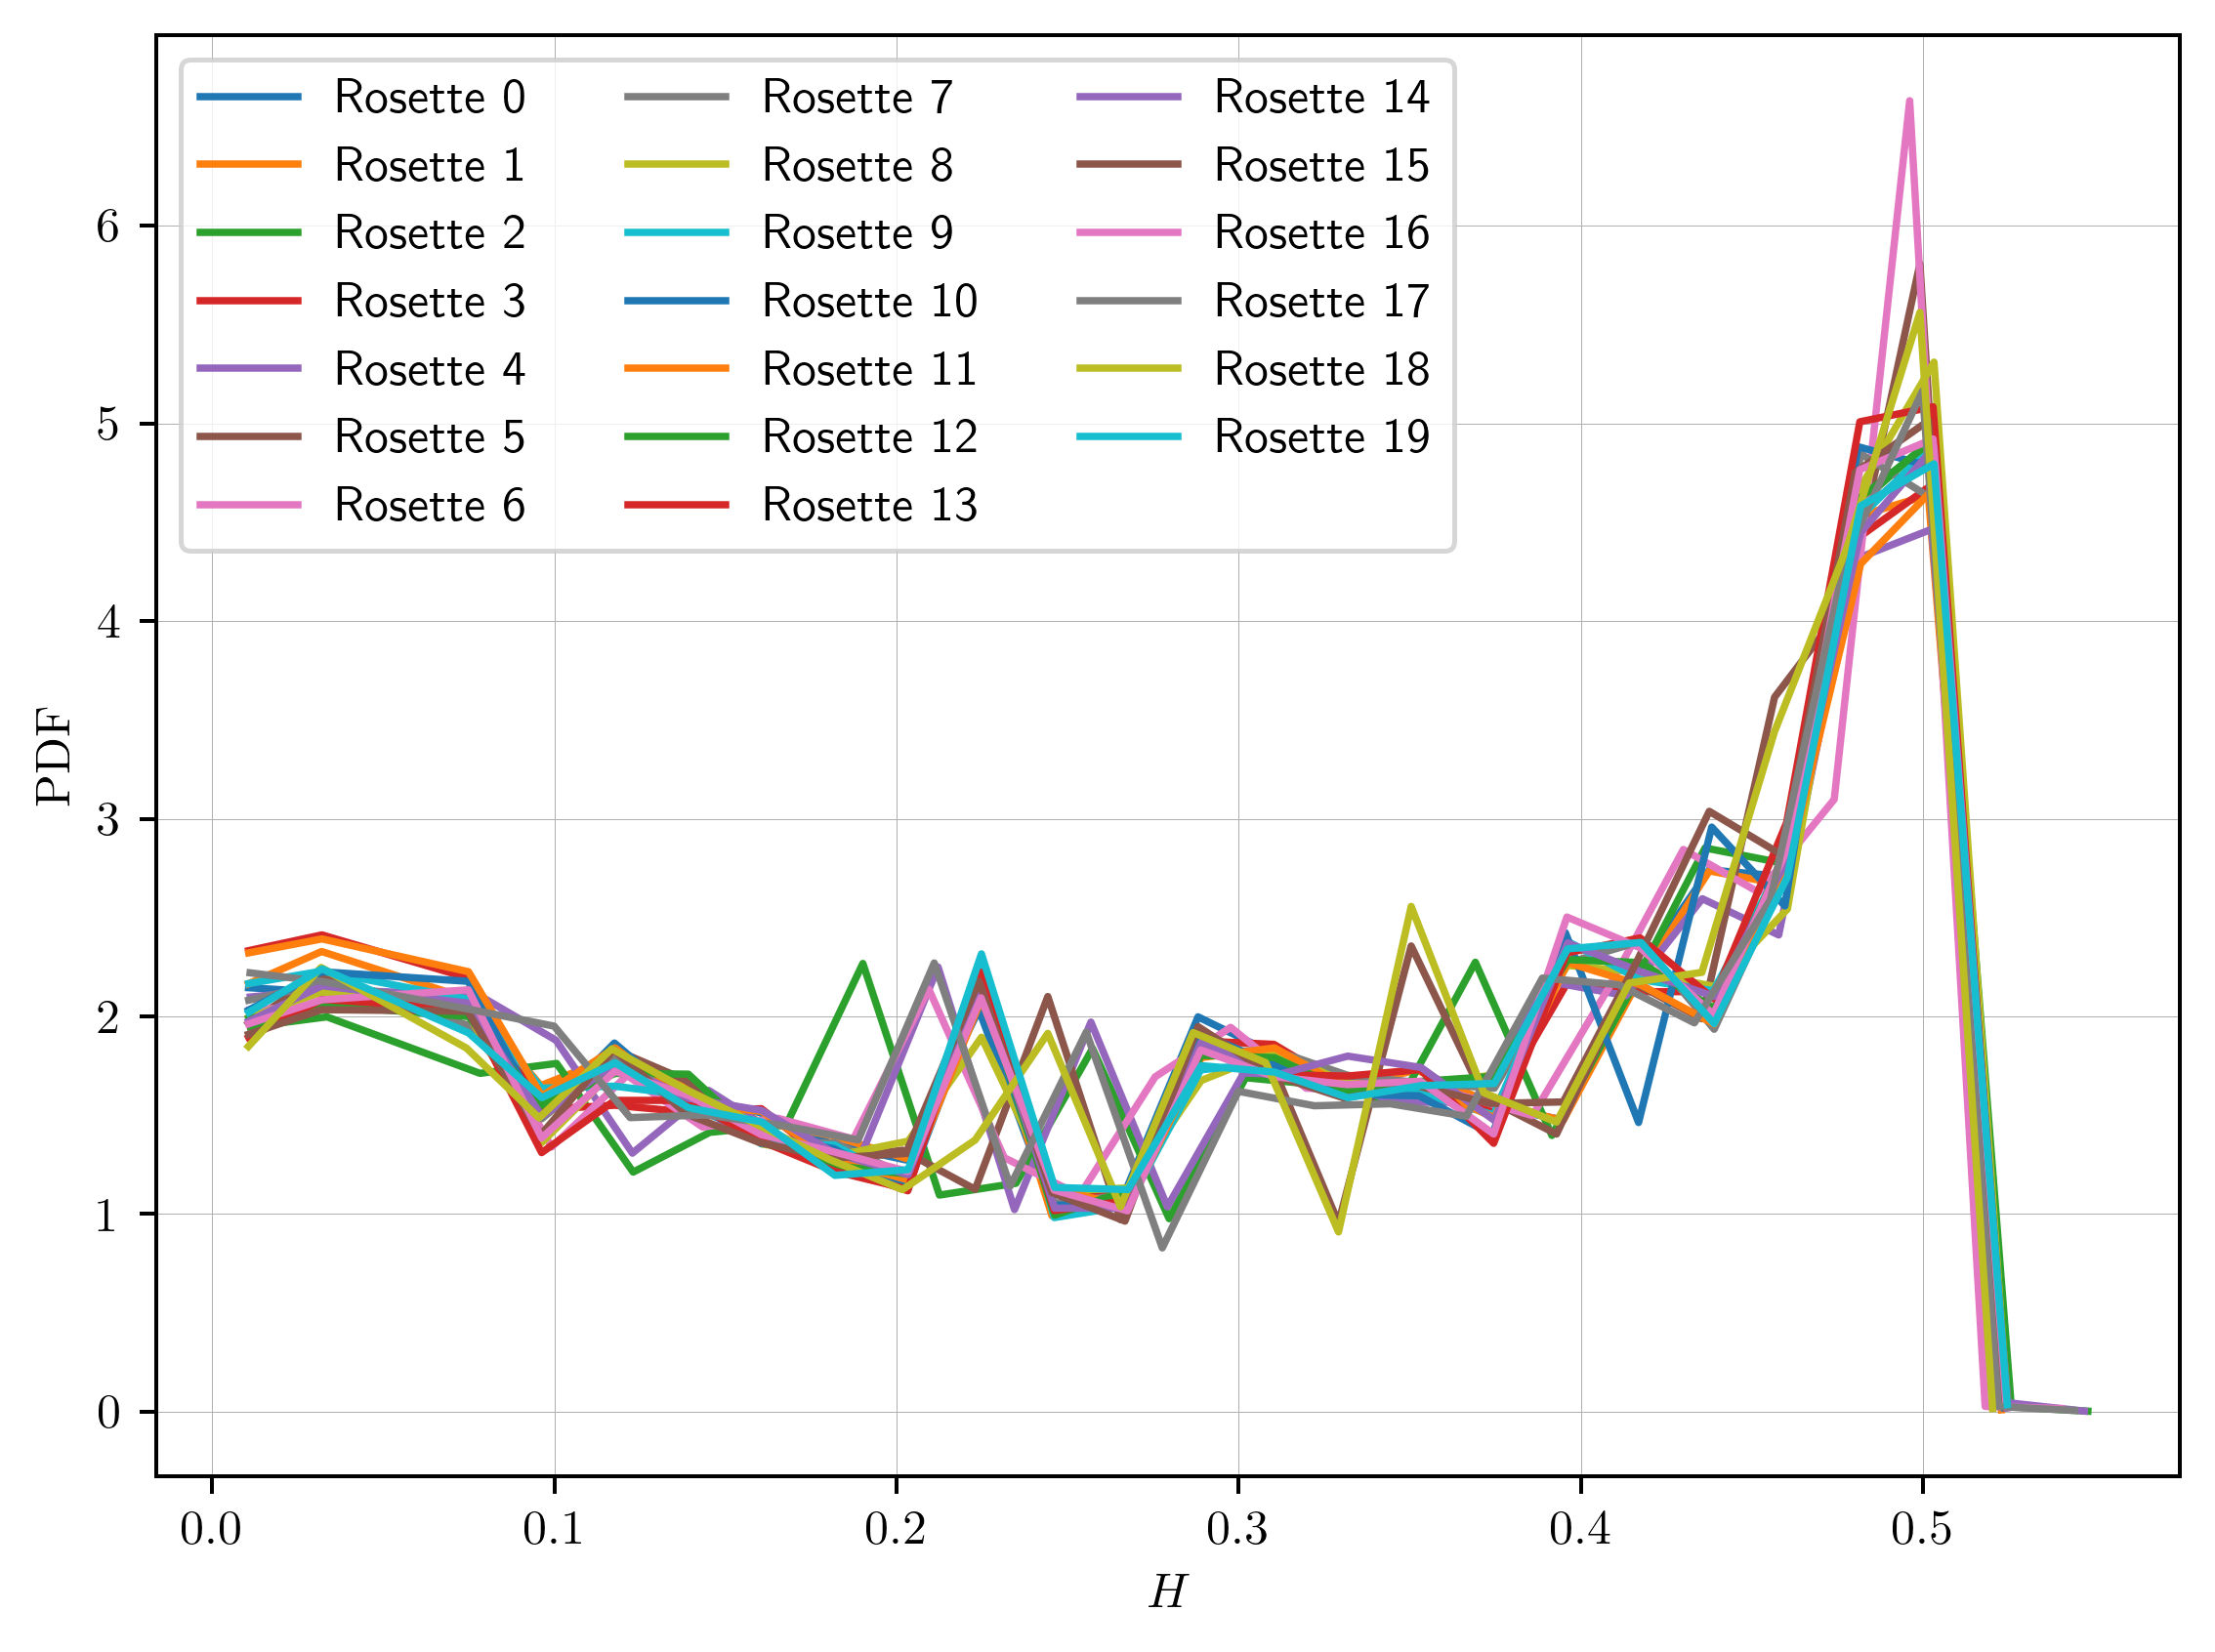

In [4]:
fig, ax = plt.subplots()
ax.grid(linewidth=0.2)

for f in fns:
    df = pd.read_csv(f)
    H = df['H'].values

    pdf, edges = np.histogram(H, bins=25, density=True)
    centers = 0.5*(edges[:-1] + edges[1:])

    rosette = int(re.search(r'rosette_(\d+)\.csv$', f).group(1))

    mask = pdf > 0
    plt.plot(centers[mask], pdf[mask], label=f'Rosette {rosette}')

plt.xlabel('$H$')
plt.ylabel(r'$\mathrm{PDF}$')
plt.legend(ncol=3, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

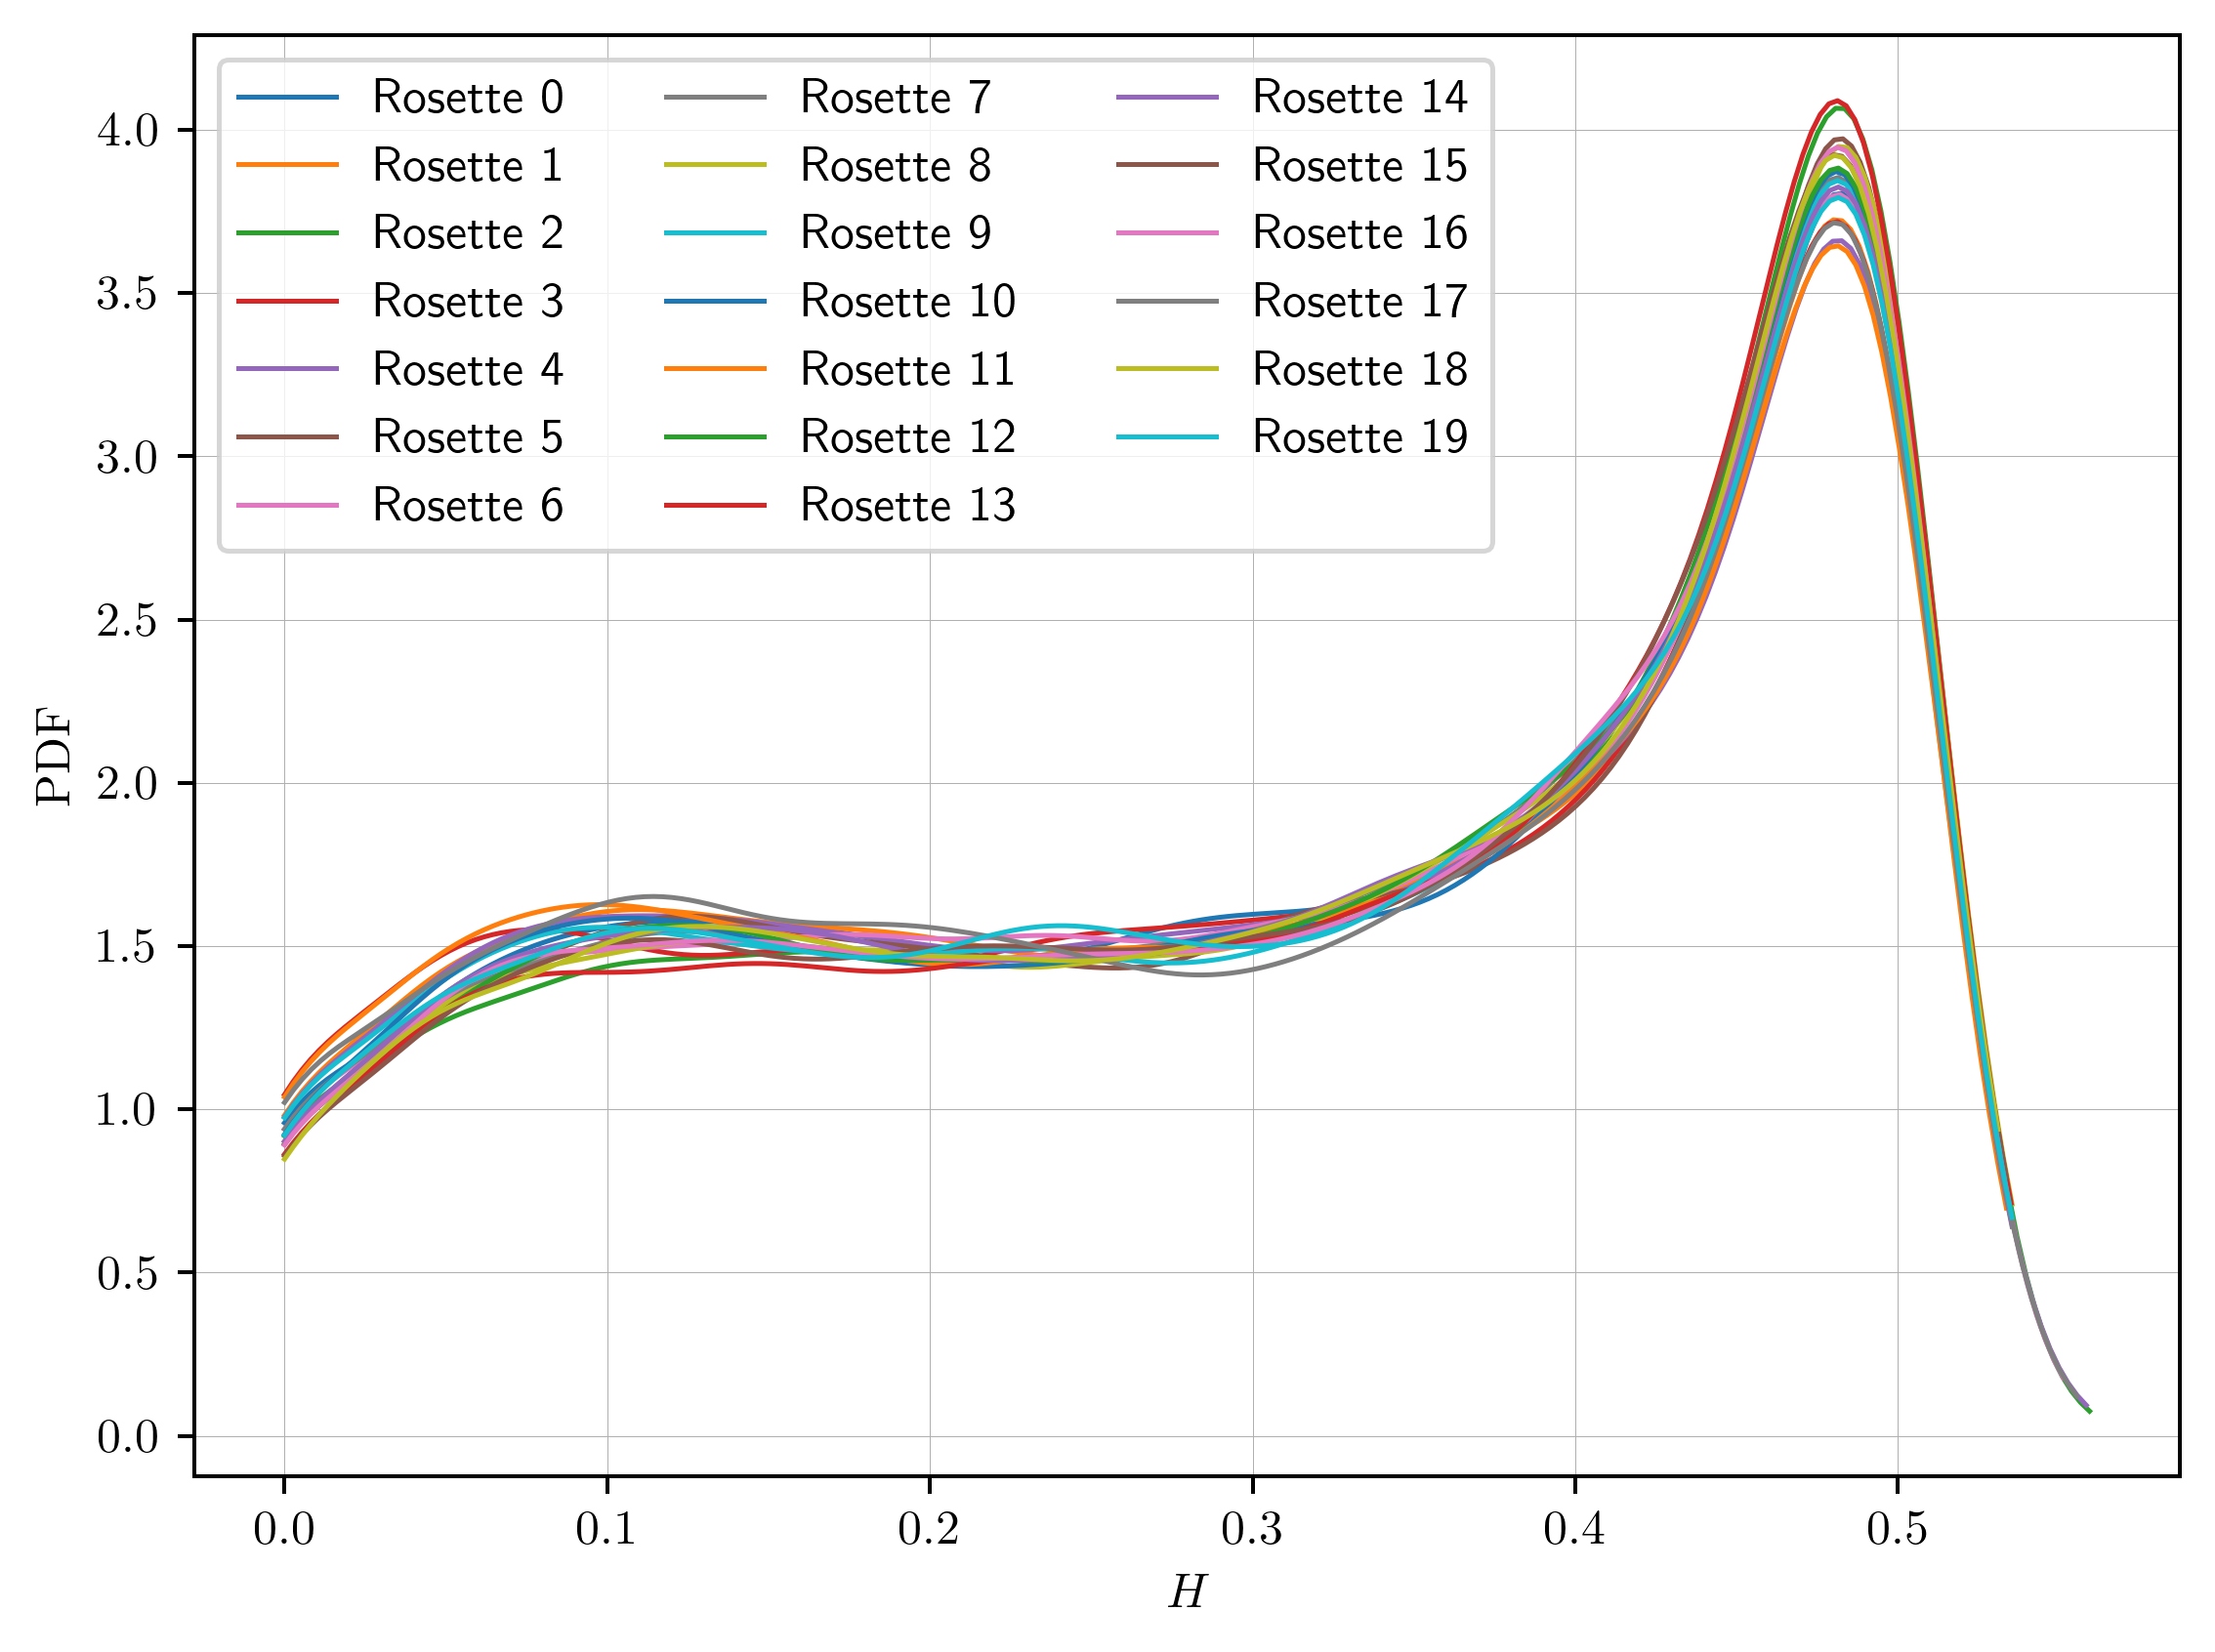

In [5]:
fig, ax = plt.subplots()
ax.grid(linewidth=0.2)

for f in fns:
    df = pd.read_csv(f)
    H = df['H'].values

    kde = gaussian_kde(H)
    x_vals = np.linspace(min(H), max(H), 200)
    pdf_vals = kde(x_vals)

    rosette = int(re.search(r'rosette_(\d+)\.csv$', f).group(1))
    plt.plot(x_vals, pdf_vals, lw=1, label=f'Rosette {rosette}')

plt.xlabel('$H$')
plt.ylabel(r'$\mathrm{PDF}$')
plt.legend(ncol=3, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

--------